<a href="https://colab.research.google.com/github/WeizmannML/course2020/blob/master/Tutorial6/Graph_Network_Tutorial_DGL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html
!pip install networkx
!pip install torchdata


Looking in links: https://data.dgl.ai/wheels/torch-2.1/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.3/797.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 M

In [ ]:
import torch
import networkx as nx
import dgl

### Let's start out of the box and draw a graph

/usr/local/lib/python3.11/dist-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


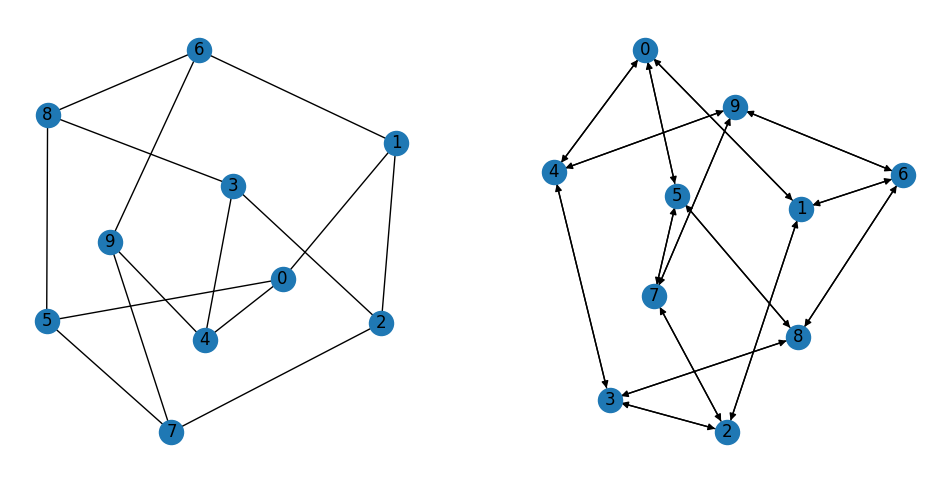

In [ ]:


g_nx = nx.petersen_graph()
g_dgl = dgl.DGLGraph(g_nx)

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,6)

plt.subplot(121)
nx.draw(g_nx, with_labels=True)
plt.subplot(122)
nx.draw(g_dgl.to_networkx(), with_labels=True)

plt.show()


### Building a graph from scratch

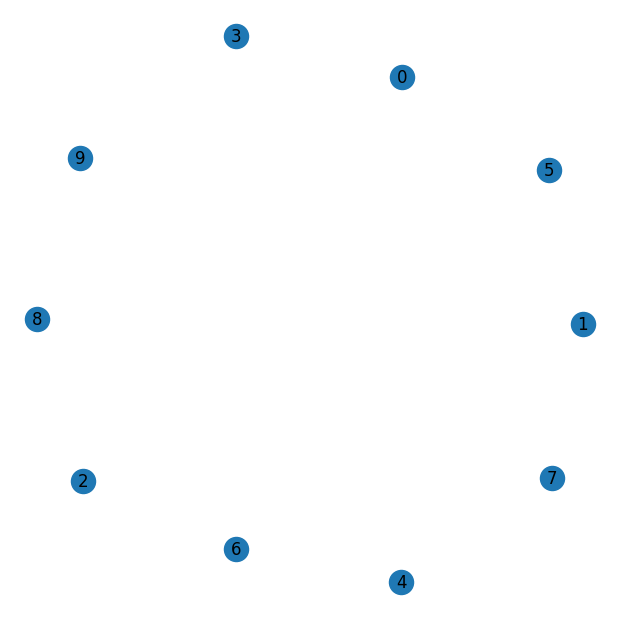

In [ ]:
import torch as th

plt.rcParams["figure.figsize"] = (6,6)
g = dgl.DGLGraph()
g.add_nodes(10)
# # a couple edges one-by-one
# for i in range(1, 4):
#     g.add_edge(i, 0)
# # a few more with a paired list
# src = list(range(5, 8)); dst = [0]*3
# g.add_edges(src, dst)
# # finish with a pair of tensors
# src = th.tensor([8, 9]); dst = th.tensor([0, 0])
# g.add_edges(src, dst)

# # edge broadcasting will do star graph in one go!
# g.clear(); g.add_nodes(10)
# src = th.tensor(list(range(1, 10)));
# g.add_edges(src, 0)

nx.draw(g.to_networkx(), with_labels=True)
plt.show()

### Define the edges with a start-node and an end-node

**### Nodes as a vector in DGL and NetworkX`**

In [ ]:
g.nodes()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
g.to_networkx().nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9))

[testo del link](https://)### Features to nodes and edges

In [ ]:
# --- creating a graph with 10 nodes -- #
g = dgl.DGLGraph()
g.add_nodes(10)

In [ ]:
g.nodes[1]

NodeSpace(data={})

In [ ]:
g.edges()

(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))

### Assigning data on the nodes

In [ ]:
x = th.randn(10, 3)
g.ndata['x'] = x # -- assigning a name to the feature : 'x'

In [ ]:
g.ndata

{'x': tensor([[-0.9271, -0.6196, -1.1241],
        [-0.8002, -1.4058,  1.2962],
        [-1.8414,  0.2767,  0.6174],
        [ 1.3801,  0.4326,  0.4589],
        [-1.2762, -1.4498,  1.1386],
        [-0.9280,  0.1273, -1.0955],
        [ 0.0382,  0.6956,  0.7756],
        [ 1.3623,  0.3409,  1.2752],
        [ 0.3776,  0.2111,  2.1706],
        [-0.5444,  0.4043,  1.1943]])}

### Data on a particular node

In [ ]:
g.nodes[3].data['x'], g.ndata['x'][3]

(tensor([[1.3801, 0.4326, 0.4589]]), tensor([1.3801, 0.4326, 0.4589]))

###  What if I want to assign features to any individual node ?

In [ ]:
# access node set with integer, list, or integer tensor
g.nodes[0].data['x'] = 2 * th.ones(1, 3)
g.nodes[[1, 2]].data['x'] = th.zeros(2, 3)


### Adding edges

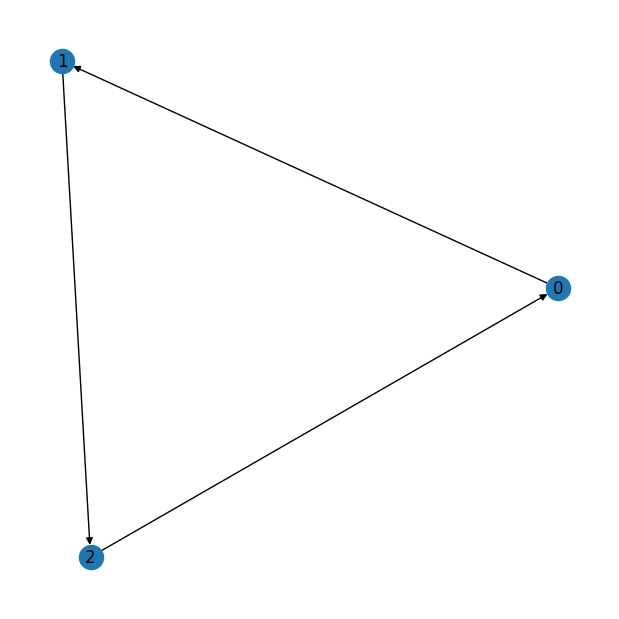

In [ ]:
# --- creating a graph with 10 nodes -- #
g = dgl.DGLGraph()
g.add_nodes(3)
src = [0, 1, 2]
dst = [1, 2, 0]
g.add_edges(src, dst)
nx.draw(g.to_networkx(), with_labels=True)
plt.show()

In [ ]:
# Define edge features
edge_features = torch.tensor([[0.1], [0.3], [0.5]])  # Example edge features

# Add features to the edges
g.edata['feat'] = edge_features
g.edata['feat']

tensor([[0.1000],
        [0.3000],
        [0.5000]])

In [ ]:
# edge broadcasting will do star graph in one go!
# --- creating a graph with 10 nodes -- #
g = dgl.DGLGraph()
g.add_nodes(10)
src = th.tensor(list(range(1, 10)));
g.add_edges(src, 0)


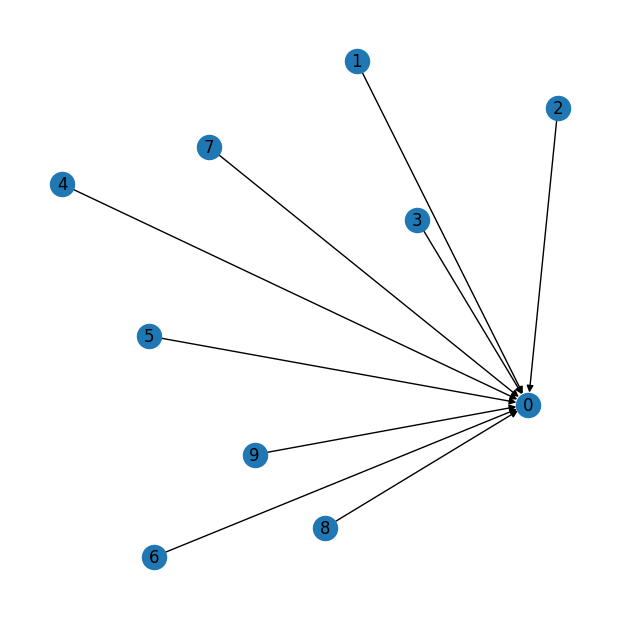

In [ ]:
nx.draw(g.to_networkx(), with_labels=True)
plt.show()

### Accessing the edges

In [ ]:
g.edges()

(tensor([1, 2, 3, 4, 5, 6, 7, 8, 9]), tensor([0, 0, 0, 0, 0, 0, 0, 0, 0]))

### How to acceess the data on the edges ?

In [ ]:
g.edges[6, 0]

EdgeSpace(data={})

In [ ]:
g.edges[6, 0].data

{}

In [ ]:
edg = g.edges[6, 0]

In [ ]:
edg.data

{}

In [ ]:
g.nodes[1]

NodeSpace(data={})

## Message passing
### a node data is updated by aggregating information from neighbouring nodes

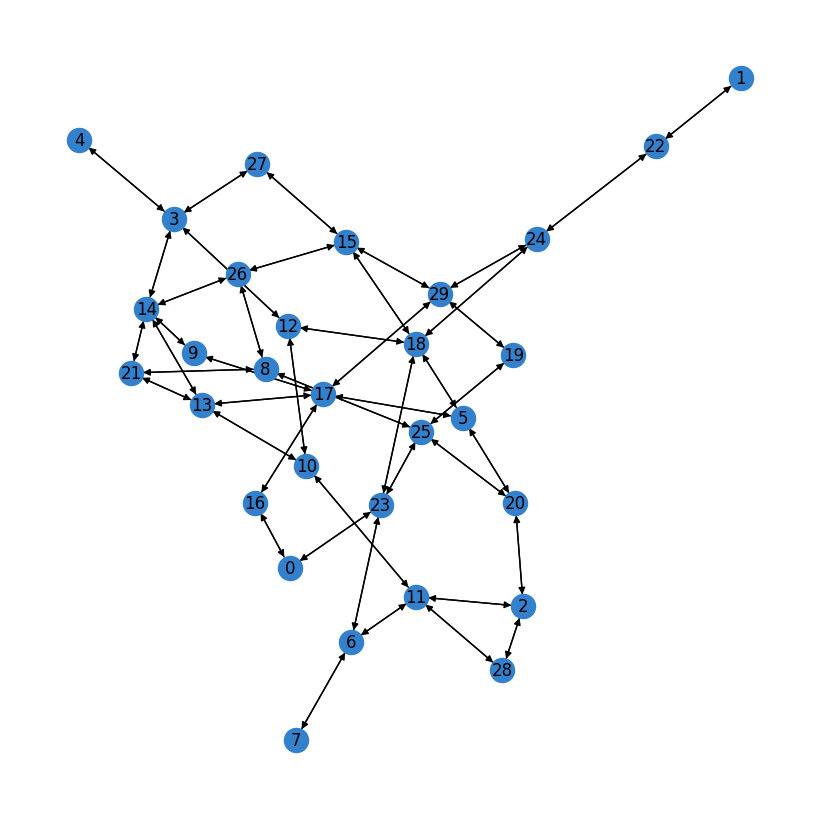

In [ ]:
N = 30  # number of nodes
DAMP = 0.85  # damping factor
g = nx.erdos_renyi_graph(N, 0.1)
g = dgl.DGLGraph(g)

plt.rcParams["figure.figsize"] = (8,8)
nx.draw(g.to_networkx(),  node_color=[[.2, .5, .8,]], with_labels=True)
plt.show()

### Assign to different data on the nodes

In [ ]:
g.ndata['pv'] = torch.ones(N) / N
g.ndata['deg'] = g.out_degrees(g.nodes()).float()

In [ ]:
g

Graph(num_nodes=30, num_edges=90,
      ndata_schemes={'pv': Scheme(shape=(), dtype=torch.float32), 'deg': Scheme(shape=(), dtype=torch.float32)}
      edata_schemes={})

In [ ]:
g.nodes()

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [ ]:
g.out_degrees(18), g.in_degrees(3), g.out_degrees(7)

(5, 4, 1)

In [ ]:
g.ndata['pv']

tensor([0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333,
        0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333,
        0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333,
        0.0333, 0.0333, 0.0333])

In [ ]:
g.ndata['deg']

tensor([2., 1., 3., 4., 1., 3., 3., 1., 3., 2., 3., 4., 3., 4., 5., 4., 2., 5.,
        5., 2., 3., 3., 2., 4., 3., 4., 3., 2., 2., 4.])

### Make four copies of the same graph for illustration purpose

### Implementation of the page rank algorithm <br> $PV(u) = \frac{1-d}{N} + d ~\times~~ \sum_{v \in \mathcal{N}(u) } \frac{PV(v)}{D(v)} $ <br> The node aggregation function is invariant under permutation of the neighbouring nodes. <br> It's a two stage process, first the 'message' is passed by each node along all the edges, originating from the node. At the next step, all the 'messages' received by a node is used to update (in a permutation invariant way) to update the node data.
https://it.wikipedia.org/wiki/PageRank

In [ ]:
import dgl.function as fn
# Define message and reduce functions
def message_func(edges):
    return {'m' : edges.src['pv'] / edges.src['deg']}   # Send 'pv' from source nodes as messages

def reduce_func(nodes):
    return {'m_sum': torch.sum(nodes.mailbox['m'], dim=1)}  # Sum received messages along dim 1


def pagerank_builtin(g):
    g.update_all(message_func=message_func, reduce_func=reduce_func)

    g.ndata['pv'] = (1 - DAMP) / N + DAMP * g.ndata['m_sum']

In [ ]:
pagerank_builtin(g)
g.ndata['pv'], g.ndata['deg']

(tensor([0.0243, 0.0232, 0.0330, 0.0400, 0.0183, 0.0315, 0.0362, 0.0185, 0.0300,
         0.0236, 0.0303, 0.0458, 0.0345, 0.0394, 0.0481, 0.0377, 0.0258, 0.0461,
         0.0466, 0.0234, 0.0320, 0.0301, 0.0303, 0.0473, 0.0400, 0.0395, 0.0314,
         0.0271, 0.0252, 0.0407]),
 tensor([2., 1., 3., 4., 1., 3., 3., 1., 3., 2., 3., 4., 3., 4., 5., 4., 2., 5.,
         5., 2., 3., 3., 2., 4., 3., 4., 3., 2., 2., 4.]))

In [ ]:
import dgl.function as fn
# Define message and reduce functions
def message_func(edges):
    return {'m' : hidden}   # Send 'pv' from source nodes as messages

def reduce_func(nodes):
    return {'m_sum': torch.sum(nodes.mailbox['m'], dim=1)}  # Sum received messages along dim 1


def sum(g):
    g.update_all(message_func=message_func, reduce_func=reduce_func)

In [ ]:
pagerank_builtin(g)
g.ndata['x']

In [ ]:

class MessageNN(nn.Module):
    def __init__(self):
        super(MessageNN, self).__init__()
        self.layer1 = nn.Linear(1, 100)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        return x